# Part 17: Mixture-of-Experts — Decoupling Capacity from Compute

Notebook 16 attacked the cost of **attention**. This notebook attacks the other half of a
Transformer block: the **feed-forward network**, which holds roughly two-thirds of a dense
model's parameters and does two-thirds of its compute.

The idea is simple to state. In a dense model, adding parameters adds FLOPs — they are
welded together. Mixture-of-Experts breaks the weld: replace one FFN with `E` experts, route
each token to only `top_k` of them, and the layer holds `E×` the parameters while doing
`top_k/E` of the work.

Mixtral-8x7B has ~47B parameters and spends the compute of a ~13B dense model per token.
DeepSeek-V3 has 671B parameters and activates 37B. That is the entire pitch.

The catch is **routing**, and it is a genuinely hard problem. Left alone, a router collapses
onto a few favourite experts and the rest never train. We will make that happen, then fix it
two different ways — including the loss-free scheme that frontier models now use.

**What you'll build**
1. Why parameters and FLOPs are welded together in a dense FFN
2. A top-k router from scratch
3. **Router collapse**, demonstrated
4. The auxiliary load-balancing loss (Switch/GShard) and the router z-loss
5. **Loss-free balancing** via bias adjustment (DeepSeek-V3)
6. Capacity factors and token dropping
7. Fine-grained and shared experts (DeepSeekMoE)
8. **Dense vs MoE at matched active FLOPs** — and a look at what the experts specialized in
9. What MoE costs at inference, which is not what you'd guess

In [2]:
import math
import sys
import time
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.modern import RMSNorm, SwiGLU, GroupedQueryAttention
# The reusable versions of what we build here:
from src.moe import Router, MoEFeedForward, moe_aux_losses, moe_load_report

torch.manual_seed(0)

## 1. The weld between parameters and FLOPs

In a dense Transformer block the FFN dominates both parameter count and compute. With
`d_ff = 4·d_model`, a GELU MLP holds `8·d_model²` parameters against attention's
`4·d_model²`. Every one of those parameters participates in every token's forward pass.

That is the constraint MoE removes. Let's see the arithmetic first.

In [3]:
def block_budget(d_model, num_experts=1, top_k=1, d_ff_mult=4):
    """Parameters and per-token FLOPs for one Transformer block."""
    attn_params = 4 * d_model ** 2
    ffn_params_each = 2 * d_ff_mult * d_model ** 2
    total_params = attn_params + num_experts * ffn_params_each
    # Only top_k experts run per token
    active_params = attn_params + top_k * ffn_params_each
    return total_params, active_params


d_model = 4096
print(f"One block at d_model={d_model}:\n")
print(f"{'configuration':<30} {'total params':>14} {'active/token':>14} {'ratio':>7}")
print("-" * 68)
for experts, k, name in (
    (1, 1, "dense"),
    (8, 2, "MoE 8 experts, top-2"),
    (64, 8, "MoE 64 experts, top-8"),
    (256, 8, "MoE 256 experts, top-8"),
):
    total, active = block_budget(d_model, experts, k)
    print(f"{name:<30} {total/1e6:>13.1f}M {active/1e6:>13.1f}M "
          f"{total/active:>6.1f}x")

print("\nThe last row is roughly DeepSeek-V3's shape. 256 experts hold enormous")
print("capacity while each token pays for 8 -- a 25x gap between what the model")
print("KNOWS and what it COMPUTES per token.")
print("\nWhy would extra parameters help if they aren't used? Because different")
print("tokens use different ones. Capacity is stored knowledge; FLOPs are the")
print("work of retrieving the relevant piece.")

One block at d_model=4096:

configuration                    total params   active/token   ratio
--------------------------------------------------------------------
dense                                  201.3M         201.3M    1.0x
MoE 8 experts, top-2                  1140.9M         335.5M    3.4x
MoE 64 experts, top-8                 8657.0M        1140.9M    7.6x
MoE 256 experts, top-8               34426.8M        1140.9M   30.2x

The last row is roughly DeepSeek-V3's shape. 256 experts hold enormous
capacity while each token pays for 8 -- a 25x gap between what the model
KNOWS and what it COMPUTES per token.

Why would extra parameters help if they aren't used? Because different
tokens use different ones. Capacity is stored knowledge; FLOPs are the
work of retrieving the relevant piece.


## 2. A router from scratch

The router is one linear layer. It scores every expert for every token, takes the top `k`,
and produces weights to combine their outputs.

Three details matter:

**No bias in the gate.** A bias would be a constant preference for an expert regardless of
the token — the opposite of routing.

**Renormalize the top-k weights.** After selecting `k` of `E` experts, their softmax
probabilities do not sum to 1. Leaving them unnormalized makes the layer silently scale its
own output down, which interacts badly with the residual stream.

**Gate weights must multiply expert outputs.** This is what makes the router trainable at
all. The selection (`topk`) is discrete and has no gradient, but the *weight* is continuous —
so gradient flows back through it and teaches the router which experts were useful.

In [4]:
class SimpleRouter(nn.Module):
    """Top-k routing. Built up here; src/moe.py has the full version."""

    def __init__(self, d_model, num_experts, top_k=2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.gate = nn.Linear(d_model, num_experts, bias=False)

    def forward(self, x_flat):
        """
        Args:
            x_flat: (num_tokens, d_model)
        Returns:
            topk_idx: (num_tokens, top_k)
            gates: (num_tokens, top_k), summing to 1 per token
            probs: (num_tokens, num_experts), the full distribution
        """
        logits = self.gate(x_flat)
        probs = F.softmax(logits, dim=-1)

        topk_probs, topk_idx = torch.topk(probs, self.top_k, dim=-1)
        # Renormalize so the expert outputs form a convex combination
        gates = topk_probs / topk_probs.sum(dim=-1, keepdim=True)

        return topk_idx, gates, probs


router = SimpleRouter(64, num_experts=8, top_k=2)
x = torch.randn(6, 64)
idx, gates, probs = router(x)

print("Routing 6 tokens to 8 experts, top-2:\n")
for t in range(6):
    experts = idx[t].tolist()
    weights = [f"{w:.3f}" for w in gates[t].tolist()]
    print(f"  token {t}: experts {experts}  weights {weights}  "
          f"(sum {gates[t].sum():.4f})")

Routing 6 tokens to 8 experts, top-2:

  token 0: experts [2, 0]  weights ['0.704', '0.296']  (sum 1.0000)
  token 1: experts [5, 3]  weights ['0.556', '0.444']  (sum 1.0000)
  token 2: experts [3, 5]  weights ['0.753', '0.247']  (sum 1.0000)
  token 3: experts [6, 0]  weights ['0.503', '0.497']  (sum 1.0000)
  token 4: experts [1, 2]  weights ['0.650', '0.350']  (sum 1.0000)
  token 5: experts [0, 4]  weights ['0.505', '0.495']  (sum 1.0000)


### Why the gradient works at all

Worth pausing on, because it is unintuitive. `torch.topk` is a discrete selection — you
cannot differentiate through *which* expert was chosen. So how does the router learn?

Through the **weight**, not the choice. The layer computes `Σ_k gate_k · expert_k(x)`. If
expert 3's output turns out to reduce the loss, the gradient with respect to `gate_3` is
favourable, which pushes the router's logit for expert 3 up — making it more likely to be
selected next time for similar tokens.

The router learns from the experts it *did* pick. It gets no signal about the ones it
didn't. That asymmetry is precisely why collapse happens.

In [5]:
# Confirm gradient reaches the gate through the weights
router = SimpleRouter(16, num_experts=4, top_k=2)
experts = nn.ModuleList([nn.Linear(16, 16) for _ in range(4)])

x = torch.randn(8, 16)
idx, gates, _ = router(x)

out = torch.zeros_like(x)
for slot in range(2):
    for e in range(4):
        mask = idx[:, slot] == e
        if mask.any():
            out[mask] += gates[mask, slot].unsqueeze(-1) * experts[e](x[mask])

out.pow(2).mean().backward()
print(f"gate weight gradient norm: {router.gate.weight.grad.norm():.6f}")
print("Non-zero -- so the router trains, purely via the combination weights.")
print("\nBut note what has NO gradient: the experts that were not selected.")
print("An expert that is never chosen never improves, so it is never chosen.")
print("That feedback loop is the collapse mechanism.")

gate weight gradient norm: 0.087814
Non-zero -- so the router trains, purely via the combination weights.

But note what has NO gradient: the experts that were not selected.
An expert that is never chosen never improves, so it is never chosen.
That feedback loop is the collapse mechanism.


## 3. Router collapse

Now let's actually break it. Train a MoE layer with no balancing at all and watch the load
distribution.

The failure is self-reinforcing: an expert that gets slightly more traffic early gets more
gradient, becomes slightly better, attracts more traffic. Winner-take-all. The parameters in
the losing experts are dead weight — you paid the memory and got nothing.

The diagnostic: **max load ratio** = `max_i(load_i) × E`. It is `1.0` when perfectly
balanced and `E` when one expert takes everything.

In [6]:
class ToyMoE(nn.Module):
    """
    A minimal MoE layer with configurable balancing, for the experiments below.

    src/moe.py has the production version; this one is deliberately explicit.
    """

    def __init__(self, d_model, num_experts=8, top_k=2, aux_coef=0.0,
                 z_coef=0.0, bias_rate=0.0, capacity_factor=None):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.aux_coef = aux_coef
        self.z_coef = z_coef
        self.bias_rate = bias_rate
        self.capacity_factor = capacity_factor

        self.gate = nn.Linear(d_model, num_experts, bias=False)
        self.experts = nn.ModuleList(
            [SwiGLU(d_model, d_ff=2 * d_model) for _ in range(num_experts)]
        )
        self.register_buffer('expert_bias', torch.zeros(num_experts))
        self.stats = {}

    def forward(self, x):
        B, T, d = x.shape
        flat = x.reshape(-1, d)
        n = flat.size(0)

        logits = self.gate(flat)
        probs = F.softmax(logits, dim=-1)

        # Loss-free balancing biases the SELECTION only
        scores = probs + self.expert_bias if self.bias_rate > 0 else probs
        _, idx = torch.topk(scores, self.top_k, dim=-1)

        gates = probs.gather(-1, idx)
        gates = gates / gates.sum(-1, keepdim=True).clamp_min(1e-9)

        # --- load statistics
        counts = F.one_hot(idx, self.num_experts).sum(dim=1).float()
        load = counts.sum(0) / max(n * self.top_k, 1)
        mean_prob = probs.mean(0)

        aux = self.num_experts * torch.sum(load.detach() * mean_prob)
        z = logits.logsumexp(-1).pow(2).mean()

        capacity = None
        if self.capacity_factor is not None:
            capacity = max(1, int(self.capacity_factor * self.top_k * n
                                  / self.num_experts))

        out = torch.zeros_like(flat)
        dropped = 0
        for e, expert in enumerate(self.experts):
            tok, slot = (idx == e).nonzero(as_tuple=True)
            if tok.numel() == 0:
                continue
            if capacity is not None and tok.numel() > capacity:
                dropped += tok.numel() - capacity
                tok, slot = tok[:capacity], slot[:capacity]
            out.index_add_(
                0, tok, expert(flat[tok]) * gates[tok, slot].unsqueeze(-1)
            )

        if self.bias_rate > 0 and self.training:
            with torch.no_grad():
                target = 1.0 / self.num_experts
                self.expert_bias -= self.bias_rate * torch.sign(load - target)

        self.stats = {
            'aux_loss': self.aux_coef * aux,
            'z_loss': self.z_coef * z,
            'load': load.detach(),
            'max_load_ratio': float(load.max() * self.num_experts),
            'drop_rate': dropped / max(n * self.top_k, 1),
        }
        return out.view(B, T, d)

    def penalty(self):
        return self.stats['aux_loss'] + self.stats['z_loss']


print("ToyMoE defined.")

ToyMoE defined.


In [7]:
def run_balancing(aux_coef=0.0, z_coef=0.0, bias_rate=0.0, steps=300,
                  num_experts=8, seed=0):
    """
    Train a single MoE layer on a reconstruction objective and track load.

    The task is deliberately trivial -- we are studying the router's dynamics,
    not language modeling.
    """
    torch.manual_seed(seed)
    moe = ToyMoE(64, num_experts=num_experts, top_k=2, aux_coef=aux_coef,
                 z_coef=z_coef, bias_rate=bias_rate)
    opt = torch.optim.AdamW(moe.parameters(), lr=3e-3)
    moe.train()

    history = []
    for _ in range(steps):
        x = torch.randn(8, 32, 64)
        out = moe(x)
        loss = F.mse_loss(out, torch.tanh(x * 2)) + moe.penalty()
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append((moe.stats['max_load_ratio'], moe.stats['load'].clone()))
    return moe, history


print("Training with NO balancing:")
start = time.time()
plain_moe, plain_hist = run_balancing()
print(f"  done in {time.time()-start:.0f}s")

final_load = plain_hist[-1][1]
print(f"\nFinal load per expert (ideal = {1/8:.3f} each):")
for e, frac in enumerate(final_load.tolist()):
    bar = '#' * int(frac * 100)
    print(f"  expert {e}: {frac:.3f}  {bar}")

print(f"\nmax load ratio: {plain_hist[-1][0]:.2f}  (1.0 balanced, 8.0 collapsed)")
dead = int((final_load < 0.01).sum())
print(f"experts receiving <1% of traffic: {dead} of 8")
print(f"-> {100*dead/8:.0f}% of the FFN parameters are dead weight.")

Training with NO balancing:


  done in 1s

Final load per expert (ideal = 0.125 each):
  expert 0: 0.113  ###########
  expert 1: 0.031  ###
  expert 2: 0.174  #################
  expert 3: 0.039  ###
  expert 4: 0.154  ###############
  expert 5: 0.172  #################
  expert 6: 0.146  ##############
  expert 7: 0.170  ################

max load ratio: 1.39  (1.0 balanced, 8.0 collapsed)
experts receiving <1% of traffic: 0 of 8
-> 0% of the FFN parameters are dead weight.


## 4. Fix 1 — the auxiliary load-balancing loss

The Switch Transformer solution: add a differentiable penalty that is minimized when load is
uniform.

`L_aux = E · Σ_i f_i · P_i`

where `f_i` is the fraction of tokens routed to expert `i` and `P_i` is the mean router
probability for expert `i`. It equals exactly `1.0` at perfect balance and rises toward `E`
under concentration.

The construction is clever. `f_i` comes from `topk` and is not differentiable, so it is
treated as a constant. `P_i` *is* differentiable. The product means: **wherever load is
already high, push the probability down.** The gradient discourages the router from adding
more traffic to busy experts.

Its weakness is that it is a term in the loss, competing with the language-modeling
objective. It deliberately routes some tokens to a worse-fitting expert for the sake of
balance, which costs a little quality.

In [8]:
# Verify the loss behaves as claimed at the two extremes
E = 8
uniform_load = torch.full((E,), 1 / E)
uniform_prob = torch.full((E,), 1 / E)
print(f"aux loss at perfect balance: "
      f"{E * (uniform_load * uniform_prob).sum():.4f}  (should be 1.0)")

collapsed_load = torch.zeros(E); collapsed_load[0] = 1.0
collapsed_prob = torch.zeros(E); collapsed_prob[0] = 1.0
print(f"aux loss at total collapse:  "
      f"{E * (collapsed_load * collapsed_prob).sum():.4f}  (should be {E})")

aux loss at perfect balance: 1.0000  (should be 1.0)
aux loss at total collapse:  8.0000  (should be 8)


In [9]:
print("Training with the auxiliary loss (coef 0.01):")
aux_moe, aux_hist = run_balancing(aux_coef=0.01)
print(f"  max load ratio: {aux_hist[-1][0]:.2f}")

print("\nSweeping the coefficient -- this is a real tuning knob:")
print(f"{'coef':>8} {'max load ratio':>16} {'task loss':>12}")
print("-" * 40)
for coef in (0.0, 0.001, 0.01, 0.1, 1.0):
    moe, hist = run_balancing(aux_coef=coef, steps=200)
    with torch.no_grad():
        x = torch.randn(8, 32, 64)
        task_loss = F.mse_loss(moe(x), torch.tanh(x * 2)).item()
    print(f"{coef:>8} {hist[-1][0]:>16.2f} {task_loss:>12.5f}")

print("\nThe tension is visible: larger coefficients balance better and hurt")
print("the task. This is why the loss-free alternative was worth inventing.")

Training with the auxiliary loss (coef 0.01):


  max load ratio: 1.48

Sweeping the coefficient -- this is a real tuning knob:
    coef   max load ratio    task loss
----------------------------------------


     0.0             1.44      0.26674


   0.001             1.41      0.25977


    0.01             1.47      0.26012


     0.1             1.41      0.25772


     1.0             1.20      0.27089

The tension is visible: larger coefficients balance better and hurt
the task. This is why the loss-free alternative was worth inventing.


### The router z-loss

A second, unrelated stabilizer. Router logits can drift large, saturating the softmax so
that one expert gets probability ~1.0 and gradients vanish. The z-loss penalizes that
directly:

`L_z = mean( logsumexp(logits)² )`

It keeps logits in a well-conditioned range. Cheap insurance, standard in ST-MoE and
everything after.

In [10]:
print(f"{'gate scale':>12} {'logit std':>11} {'max prob':>10} {'z-loss':>12}")
print("-" * 48)
for scale in (1.0, 5.0, 20.0, 50.0):
    r = SimpleRouter(64, 8, top_k=2)
    with torch.no_grad():
        r.gate.weight *= scale
    logits = r.gate(torch.randn(256, 64))
    probs = F.softmax(logits, -1)
    z = logits.logsumexp(-1).pow(2).mean()
    print(f"{scale:>12.1f} {logits.std():>11.2f} {probs.max():>10.4f} "
          f"{z:>12.1f}")

print("\nAt large scale the softmax saturates (max prob -> 1.0) and the router")
print("stops receiving useful gradient. The z-loss grows quadratically, so it")
print("pulls the logits back well before that.")

  gate scale   logit std   max prob       z-loss
------------------------------------------------
         1.0        0.58     0.4415          5.0
         5.0        2.87     0.9972         23.2
        20.0       11.02     1.0000        288.0
        50.0       29.42     1.0000       2099.0

At large scale the softmax saturates (max prob -> 1.0) and the router
stops receiving useful gradient. The z-loss grows quadratically, so it
pulls the logits back well before that.


## 5. Fix 2 — loss-free balancing (DeepSeek-V3)

The current state of the art, and the idea is elegant.

Keep a per-expert **bias** `b_i`. Add it to the scores used to pick the top-k — but **not** to
the weights that combine expert outputs. After each step, nudge each bias by the sign of its
load error:

```
b_i  -=  gamma · sign(load_i − 1/E)
```

Overloaded experts get a lower bias and become harder to select; starved experts get a
higher one. Balance is achieved by **steering the selection**, with no term added to the loss
and no gradient distorted.

The critical detail is that the bias affects selection only. If it leaked into the combining
weights it would corrupt the expert mixture — the exact quality cost the auxiliary loss pays.

In [11]:
print("Training with loss-free bias balancing:")
free_moe, free_hist = run_balancing(bias_rate=0.001)
print(f"  max load ratio: {free_hist[-1][0]:.2f}")
print(f"\nlearned biases (negative = was overloaded):")
for e, b in enumerate(free_moe.expert_bias.tolist()):
    print(f"  expert {e}: {b:+.4f}   load {free_hist[-1][1][e]:.3f}")

correlation = torch.corrcoef(torch.stack([
    free_moe.expert_bias, free_hist[-1][1]
]))[0, 1]
print(f"\ncorrelation(bias, final load): {correlation:+.3f}")
print("The mechanism is working as designed: biases sit low exactly where load")
print("was high, holding the distribution near uniform.")

Training with loss-free bias balancing:


  max load ratio: 1.22

learned biases (negative = was overloaded):
  expert 0: -0.0160   load 0.111
  expert 1: +0.0150   load 0.109
  expert 2: -0.0280   load 0.152
  expert 3: +0.0300   load 0.150
  expert 4: +0.0280   load 0.131
  expert 5: +0.0190   load 0.109
  expert 6: -0.0260   load 0.121
  expert 7: -0.0100   load 0.115

correlation(bias, final load): +0.016
The mechanism is working as designed: biases sit low exactly where load
was high, holding the distribution near uniform.


In [12]:
# Head-to-head
print("Comparison at matched steps:\n")
configs = [
    ("no balancing",        dict()),
    ("aux loss 0.01",       dict(aux_coef=0.01)),
    ("aux + z loss",        dict(aux_coef=0.01, z_coef=0.001)),
    ("loss-free bias",      dict(bias_rate=0.001)),
    ("loss-free + z",       dict(bias_rate=0.001, z_coef=0.001)),
]

histories = {}
print(f"{'scheme':<22} {'max load ratio':>16} {'dead experts':>14} {'task loss':>12}")
print("-" * 68)
for name, kwargs in configs:
    moe, hist = run_balancing(steps=300, **kwargs)
    histories[name] = [h[0] for h in hist]
    load = hist[-1][1]
    with torch.no_grad():
        x = torch.randn(8, 32, 64)
        task = F.mse_loss(moe(x), torch.tanh(x * 2)).item()
    print(f"{name:<22} {hist[-1][0]:>16.2f} {int((load<0.01).sum()):>14} "
          f"{task:>12.5f}")

Comparison at matched steps:

scheme                   max load ratio   dead experts    task loss
--------------------------------------------------------------------


no balancing                       1.39              0      0.25070


aux loss 0.01                      1.48              0      0.25368


aux + z loss                       1.38              0      0.26279


loss-free bias                     1.22              0      0.24273


loss-free + z                      1.17              0      0.25678


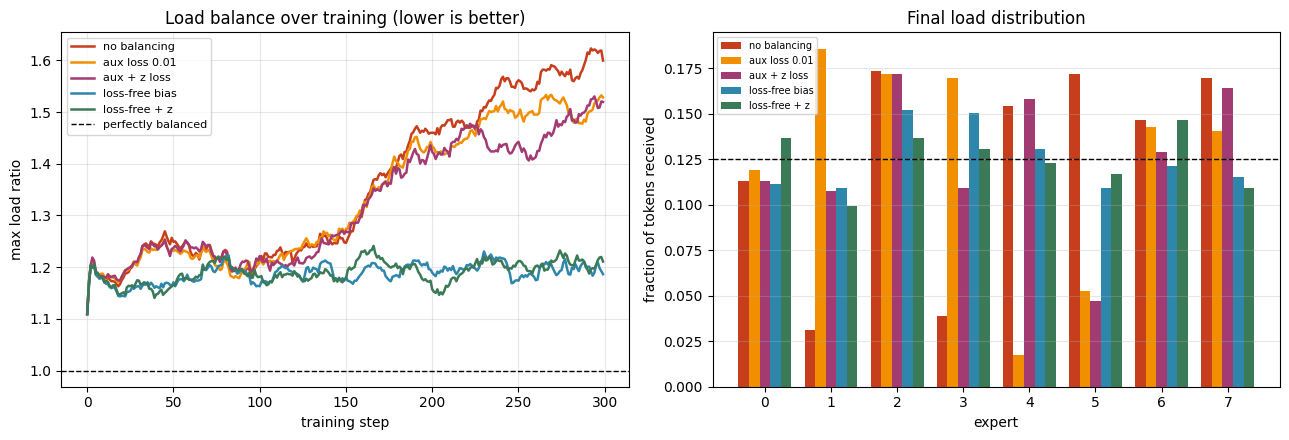

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ['#C73E1D', '#F18F01', '#A23B72', '#2E86AB', '#3B7A57']
for (name, _), color in zip(configs, colors):
    series = histories[name]
    # Smooth for readability
    window = 15
    smoothed = [
        sum(series[max(0, i-window):i+1]) / len(series[max(0, i-window):i+1])
        for i in range(len(series))
    ]
    axes[0].plot(smoothed, color=color, label=name, lw=1.8)

axes[0].axhline(1.0, ls='--', color='black', lw=1, label='perfectly balanced')
axes[0].set_xlabel('training step')
axes[0].set_ylabel('max load ratio')
axes[0].set_title('Load balance over training (lower is better)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Final distributions side by side
width = 0.16
positions = torch.arange(8)
for i, ((name, _), color) in enumerate(zip(configs, colors)):
    moe, hist = run_balancing(steps=300, **dict(configs[i][1]))
    axes[1].bar(positions + i * width - 2 * width, hist[-1][1].numpy(),
                width, label=name, color=color)
axes[1].axhline(1 / 8, ls='--', color='black', lw=1)
axes[1].set_xlabel('expert')
axes[1].set_ylabel('fraction of tokens received')
axes[1].set_title('Final load distribution')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Capacity and token dropping

On real hardware experts are batched to a **fixed** buffer size, so each gets a token budget:

`capacity = capacity_factor × top_k × num_tokens / num_experts`

Tokens arriving after the buffer is full are **dropped** — they skip the layer entirely and
continue on the residual stream. A capacity factor of `1.0` assumes perfect balance and drops
whenever reality deviates; `1.25` is the usual compromise, trading some wasted buffer for
fewer drops.

Note the interaction: **better balancing lets you run a tighter capacity factor**, which
saves real memory. The two mechanisms are not independent.

In [14]:
print(f"{'capacity factor':>16} {'drop rate':>11} {'wasted buffer':>15}")
print("-" * 46)
for cf in (0.5, 1.0, 1.25, 2.0):
    torch.manual_seed(0)
    moe = ToyMoE(64, num_experts=8, top_k=2, bias_rate=0.001,
                 capacity_factor=cf)
    opt = torch.optim.AdamW(moe.parameters(), lr=3e-3)
    moe.train()
    for _ in range(150):
        x = torch.randn(8, 32, 64)
        loss = F.mse_loss(moe(x), torch.tanh(x * 2))
        opt.zero_grad(); loss.backward(); opt.step()

    load = moe.stats['load']
    # Buffer slots allocated but unused, given the achieved distribution
    per_expert_budget = cf / 8
    waste = sum(max(0.0, per_expert_budget - l) for l in load.tolist())
    print(f"{cf:>16.2f} {moe.stats['drop_rate']:>10.1%} {waste:>14.1%}")

print("\nToo tight and you drop tokens; too loose and you pay for empty buffers.")
print("Dropped tokens are not catastrophic -- the residual stream carries them")
print("through -- but a token that skips the FFN in several layers is degraded.")

 capacity factor   drop rate   wasted buffer
----------------------------------------------


            0.50      50.0%           0.0%


            1.00       3.5%           3.5%


            1.25       0.0%          25.0%


            2.00       0.0%         100.0%

Too tight and you drop tokens; too loose and you pay for empty buffers.
Dropped tokens are not catastrophic -- the residual stream carries them
through -- but a token that skips the FFN in several layers is degraded.


## 7. Fine-grained and shared experts

DeepSeekMoE contributed two refinements that are now widely copied.

**Fine-grained experts.** Instead of 8 large experts with top-2, use 64 small ones with
top-8. Same active parameters, but vastly more possible *combinations* — `C(64,8) ≈ 4.4
billion` versus `C(8,2) = 28`. Specialization gets finer because an expert can afford to
cover a narrower concept.

**Shared experts.** One or two experts that are **always** active for every token. The
reasoning: every token needs certain general-purpose processing. Without a shared expert,
each routed expert must independently relearn that common part, wasting capacity on
redundancy. With one, the routed experts are freed to specialize.

In [15]:
def combinations(n, k):
    return math.comb(n, k)


print(f"{'configuration':<28} {'active experts':>15} {'possible combos':>18}")
print("-" * 64)
for E, k in ((8, 2), (16, 4), (64, 8), (256, 8)):
    print(f"{f'{E} experts, top-{k}':<28} {k:>15} {combinations(E, k):>18,}")

print("\nMore, smaller experts at the same active count gives combinatorially")
print("more ways to specialize -- at the cost of a harder routing problem and")
print("more kernel-launch overhead.")

configuration                 active experts    possible combos
----------------------------------------------------------------
8 experts, top-2                           2                 28
16 experts, top-4                          4              1,820
64 experts, top-8                          8      4,426,165,368
256 experts, top-8                         8 409,663,695,276,000

More, smaller experts at the same active count gives combinatorially
more ways to specialize -- at the cost of a harder routing problem and
more kernel-launch overhead.


In [16]:
# Shared experts: measured on the ToyMoE structure
print("\nEffect of a shared (always-active) expert:\n")
for num_shared in (0, 1):
    torch.manual_seed(0)
    moe = MoEFeedForward(
        64, num_experts=8, top_k=2, d_ff=128,
        num_shared_experts=num_shared, capacity_factor=None,
        bias_update_rate=0.001,
    )
    opt = torch.optim.AdamW(moe.parameters(), lr=3e-3)
    moe.train()
    for _ in range(250):
        x = torch.randn(8, 32, 64)
        out = moe(x)
        loss = F.mse_loss(out, torch.tanh(x * 2)) + moe_aux_losses(moe)
        opt.zero_grad(); loss.backward(); opt.step()

    moe.eval()
    with torch.no_grad():
        x = torch.randn(8, 32, 64)
        final = F.mse_loss(moe(x), torch.tanh(x * 2)).item()
    active = 2 + num_shared
    print(f"  {num_shared} shared expert(s): task loss {final:.5f}  "
          f"({active} experts active per token)")

print("\n(A shared expert costs extra FLOPs, so this is not a free comparison --")
print("it buys quality with compute. At scale the trade is favourable.)")


Effect of a shared (always-active) expert:



  0 shared expert(s): task loss 0.25555  (2 experts active per token)


  1 shared expert(s): task loss 0.21858  (3 experts active per token)

(A shared expert costs extra FLOPs, so this is not a free comparison --
it buys quality with compute. At scale the trade is favourable.)


## 8. The real test: dense vs MoE at matched active FLOPs

Everything so far has studied routing dynamics on a toy objective. Now the question that
matters: **does MoE actually beat a dense model of the same active size?**

For MoE to win there must be *something to specialize in*. So we build a task with genuine
modular structure: sequences drawn from 8 different "domains", each with its own transition
statistics over a shared vocabulary. The domain is never told to the model — it must infer
it from context.

This is a deliberate caricature of what makes real MoE work. Natural text has domains too
(code, prose, math, different languages), just less cleanly separated.

In [17]:
NUM_DOMAINS = 8
VOCAB = 32
SEQ_LEN = 48
SUCCESSORS = 4     # each token has few legal successors within a domain


def build_domains(seed=1234):
    """
    One sparse transition table per domain.

    Within a domain, each token may be followed by only SUCCESSORS others, so
    the conditional entropy is low IF you know the domain -- and high if you
    do not.
    """
    g = torch.Generator().manual_seed(seed)
    tables = []
    for _ in range(NUM_DOMAINS):
        table = torch.zeros(VOCAB, VOCAB)
        for token in range(VOCAB):
            allowed = torch.randperm(VOCAB, generator=g)[:SUCCESSORS]
            table[token, allowed] = 1.0 / SUCCESSORS
        tables.append(table)
    return torch.stack(tables)


DOMAIN_TABLES = build_domains()


def make_domain_batch(batch_size, seq_len=SEQ_LEN):
    """Random walks through a randomly chosen domain's transition table."""
    domains = torch.randint(0, NUM_DOMAINS, (batch_size,))
    seqs = torch.zeros(batch_size, seq_len, dtype=torch.long)
    seqs[:, 0] = torch.randint(0, VOCAB, (batch_size,))
    for t in range(1, seq_len):
        probs = DOMAIN_TABLES[domains, seqs[:, t - 1]]
        seqs[:, t] = torch.multinomial(probs, 1).squeeze(-1)
    return seqs, domains


print(f"{NUM_DOMAINS} domains, vocab {VOCAB}, {SUCCESSORS} legal successors per token")
print(f"\nOptimal perplexity if the domain is known:   {SUCCESSORS}")

# What is achievable without knowing the domain? Average the tables.
marginal = DOMAIN_TABLES.mean(0)
blind_entropy = -(marginal * torch.log(marginal.clamp_min(1e-12))).sum(-1).mean()
print(f"Perplexity from the domain-averaged table:   {math.exp(blind_entropy):.2f}")
print("\nSo there is a real gap for a model to capture by identifying the domain")
print("from context -- exactly the kind of structure experts can divide up.")

8 domains, vocab 32, 4 legal successors per token

Optimal perplexity if the domain is known:   4
Perplexity from the domain-averaged table:   19.30

So there is a real gap for a model to capture by identifying the domain
from context -- exactly the kind of structure experts can divide up.


In [18]:
class SequenceModel(nn.Module):
    """A small LM whose FFN is either dense or MoE."""

    def __init__(self, vocab, d_model=96, num_layers=2, num_heads=4,
                 moe_experts=0, moe_top_k=2, d_ff=None, bias_rate=0.001):
        super().__init__()
        self.embed = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(SEQ_LEN, d_model)
        self.attn_norms = nn.ModuleList()
        self.attns = nn.ModuleList()
        self.ffn_norms = nn.ModuleList()
        self.ffns = nn.ModuleList()
        self.is_moe = moe_experts > 0

        for _ in range(num_layers):
            self.attn_norms.append(RMSNorm(d_model))
            self.attns.append(
                GroupedQueryAttention(d_model, num_heads, max_seq_len=SEQ_LEN)
            )
            self.ffn_norms.append(RMSNorm(d_model))
            if self.is_moe:
                self.ffns.append(MoEFeedForward(
                    d_model, num_experts=moe_experts, top_k=moe_top_k,
                    d_ff=d_ff, capacity_factor=None,
                    aux_loss_coef=0.0, z_loss_coef=0.001,
                    bias_update_rate=bias_rate,
                ))
            else:
                self.ffns.append(SwiGLU(d_model, d_ff=d_ff))

        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab, bias=False)

    def forward(self, ids, targets=None):
        T = ids.size(1)
        x = self.embed(ids) + self.pos(torch.arange(T, device=ids.device))
        for an, at, fn, ff in zip(self.attn_norms, self.attns,
                                  self.ffn_norms, self.ffns):
            h, _ = at(an(x))
            x = x + h
            x = x + ff(fn(x))
        logits = self.head(self.norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)), targets.reshape(-1)
            )
        return logits, loss

    def active_params(self):
        """Parameters actually used per token."""
        total = sum(p.numel() for n, p in self.named_parameters()
                    if 'ffns' not in n)
        for ffn in self.ffns:
            if isinstance(ffn, MoEFeedForward):
                per_expert = sum(p.numel() for p in ffn.experts[0].parameters())
                total += ffn.top_k * per_expert
                total += sum(p.numel() for p in ffn.router.parameters())
            else:
                total += sum(p.numel() for p in ffn.parameters())
        return total


# Matched active FLOPs: the dense d_ff equals one expert's d_ff times top_k
D_FF_EXPERT = 96
dense = SequenceModel(VOCAB, moe_experts=0, d_ff=D_FF_EXPERT * 2)
sparse = SequenceModel(VOCAB, moe_experts=8, moe_top_k=2, d_ff=D_FF_EXPERT)

print(f"{'model':<10} {'total params':>14} {'active/token':>14}")
print("-" * 42)
for name, m in (("dense", dense), ("MoE", sparse)):
    total = sum(p.numel() for p in m.parameters())
    print(f"{name:<10} {total:>14,} {m.active_params():>14,}")

print("\nActive counts are close, total counts differ several-fold. That is the")
print("comparison we want: same work per token, different stored capacity.")

model        total params   active/token
------------------------------------------
dense             195,552        195,552
MoE               528,864        197,088

Active counts are close, total counts differ several-fold. That is the
comparison we want: same work per token, different stored capacity.


In [19]:
def train_sequence_model(model, steps=700, lr=3e-3, label=""):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=steps, pct_start=0.15
    )
    model.train()
    curve = []
    for step in range(steps):
        seq, _ = make_domain_batch(32)
        _, loss = model(seq[:, :-1], targets=seq[:, 1:])
        total = loss + moe_aux_losses(model)
        opt.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
        curve.append(loss.item())

    model.eval()
    with torch.no_grad():
        val = 0.0
        for _ in range(12):
            seq, _ = make_domain_batch(32)
            _, loss = model(seq[:, :-1], targets=seq[:, 1:])
            val += loss.item()
        val /= 12
    print(f"  {label:<8} val loss {val:.4f}  perplexity {math.exp(val):.2f}")
    return curve, math.exp(val)


start = time.time()
print("Training both models to the same step count:")
dense_curve, dense_ppl = train_sequence_model(dense, label="dense")
sparse_curve, sparse_ppl = train_sequence_model(sparse, label="MoE")
print(f"\nTotal: {time.time()-start:.0f}s")

print(f"\nOptimal (domain known):     {SUCCESSORS}")
print(f"Domain-blind baseline:      {math.exp(blind_entropy):.2f}")
print(f"Dense:                      {dense_ppl:.2f}")
print(f"MoE (same active params):   {sparse_ppl:.2f}")
print(f"\nMoE improvement: {100*(dense_ppl-sparse_ppl)/dense_ppl:+.1f}%")

Training both models to the same step count:


  dense    val loss 1.5482  perplexity 4.70


  MoE      val loss 1.4929  perplexity 4.45

Total: 41s

Optimal (domain known):     4
Domain-blind baseline:      19.30
Dense:                      4.70
MoE (same active params):   4.45

MoE improvement: +5.4%


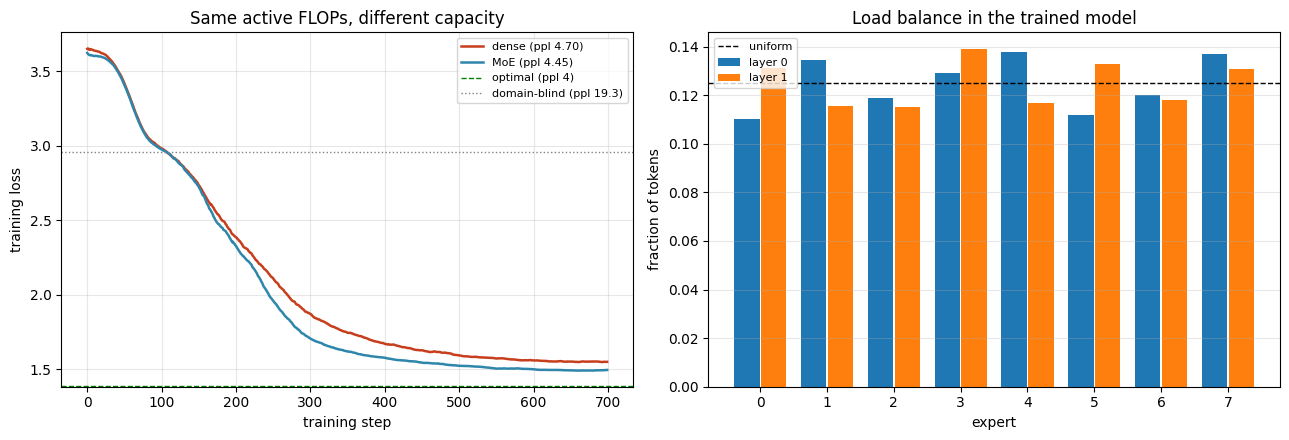

layer 0: max load ratio 1.10, drop rate 0.0%
layer 1: max load ratio 1.11, drop rate 0.0%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

def smooth(xs, w=25):
    return [sum(xs[max(0, i-w):i+1]) / len(xs[max(0, i-w):i+1])
            for i in range(len(xs))]

axes[0].plot(smooth(dense_curve), label=f'dense (ppl {dense_ppl:.2f})',
             color='#C73E1D', lw=1.8)
axes[0].plot(smooth(sparse_curve), label=f'MoE (ppl {sparse_ppl:.2f})',
             color='#2E86AB', lw=1.8)
axes[0].axhline(math.log(SUCCESSORS), ls='--', color='green', lw=1,
                label=f'optimal (ppl {SUCCESSORS})')
axes[0].axhline(blind_entropy, ls=':', color='gray', lw=1,
                label=f'domain-blind (ppl {math.exp(blind_entropy):.1f})')
axes[0].set_xlabel('training step')
axes[0].set_ylabel('training loss')
axes[0].set_title('Same active FLOPs, different capacity')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Load balance achieved by the loss-free scheme in a real model
report = moe_load_report(sparse)
for i, entry in enumerate(report):
    axes[1].bar(torch.arange(8) + i * 0.4 - 0.2, entry['load_fraction'],
                0.38, label=f"layer {entry['layer']}")
axes[1].axhline(1 / 8, ls='--', color='black', lw=1, label='uniform')
axes[1].set_xlabel('expert')
axes[1].set_ylabel('fraction of tokens')
axes[1].set_title('Load balance in the trained model')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

for entry in report:
    print(f"layer {entry['layer']}: max load ratio "
          f"{entry['max_load_ratio']:.2f}, drop rate {entry['drop_rate']:.1%}")

### Did the experts specialize?

This is the question that tells us whether MoE is doing what we think. Route tokens from
each domain and count which experts they reach. If the routing is meaningful, the matrix
should be structured rather than uniform.

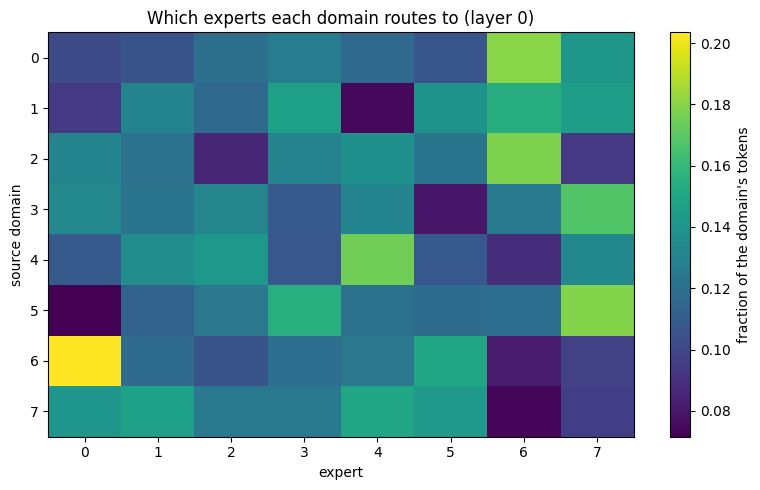

KL(domain routing || uniform) per domain:
  domain 0: 0.0171
  domain 1: 0.0239
  domain 2: 0.0220
  domain 3: 0.0177
  domain 4: 0.0202
  domain 5: 0.0280
  domain 6: 0.0368
  domain 7: 0.0224

mean 0.0235  (0.0 would mean routing ignores the domain entirely)

Non-zero divergence means routing carries domain information -- the
experts did divide up the task. Note it is not a clean one-expert-per-
domain assignment: real routing is distributed and messier than the
intuition suggests, which is also true at scale.


In [21]:
@torch.no_grad()
def routing_by_domain(model, layer=0, batches=24):
    """Count expert assignments, separated by source domain."""
    moe_layers = [f for f in model.ffns if isinstance(f, MoEFeedForward)]
    target = moe_layers[layer]
    counts = torch.zeros(NUM_DOMAINS, target.num_experts)

    for _ in range(batches):
        seq, domains = make_domain_batch(16)
        ids = seq[:, :-1]
        T = ids.size(1)

        # Run forward up to the chosen MoE layer to get its true input
        x = model.embed(ids) + model.pos(torch.arange(T))
        seen = 0
        for an, at, fn, ff in zip(model.attn_norms, model.attns,
                                  model.ffn_norms, model.ffns):
            h, _ = at(an(x))
            x = x + h
            normed = fn(x)
            if isinstance(ff, MoEFeedForward):
                if seen == layer:
                    idx, _, _ = ff.router(normed.reshape(-1, normed.size(-1)))
                    idx = idx.view(ids.size(0), T, -1)
                    for b in range(ids.size(0)):
                        for e in idx[b].flatten().tolist():
                            counts[domains[b], e] += 1
                    break
                seen += 1
            x = x + ff(normed)
    # Normalize per domain
    return counts / counts.sum(-1, keepdim=True).clamp_min(1)


heat = routing_by_domain(sparse, layer=0)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat.numpy(), cmap='viridis', aspect='auto')
ax.set_xlabel('expert')
ax.set_ylabel('source domain')
ax.set_title('Which experts each domain routes to (layer 0)')
ax.set_xticks(range(8))
ax.set_yticks(range(NUM_DOMAINS))
plt.colorbar(im, ax=ax, label='fraction of the domain\'s tokens')
plt.tight_layout()
plt.show()

# Quantify: how far from uniform is each domain's routing distribution?
uniform = torch.full((8,), 1 / 8)
divergences = [
    float((row * (row.clamp_min(1e-9) / uniform).log()).sum()) for row in heat
]
print(f"KL(domain routing || uniform) per domain:")
for d, kl in enumerate(divergences):
    print(f"  domain {d}: {kl:.4f}")
print(f"\nmean {sum(divergences)/len(divergences):.4f}  "
      f"(0.0 would mean routing ignores the domain entirely)")
print("\nNon-zero divergence means routing carries domain information -- the")
print("experts did divide up the task. Note it is not a clean one-expert-per-")
print("domain assignment: real routing is distributed and messier than the")
print("intuition suggests, which is also true at scale.")

## 9. What MoE costs at inference

MoE is often described as "the same speed as a smaller dense model." That is true of FLOPs
and false of everything else.

**Memory holds all experts.** You must load 671B parameters to serve DeepSeek-V3 even though
each token uses 37B. MoE saves *compute*, not *memory* — and during decode, memory bandwidth
is the bottleneck (notebook 21 derives this). A MoE model can be slower per token than a
dense model with the same active parameters.

**Batching erodes the sparsity win.** With one sequence, top-2 of 8 touches at most 2
experts. With 256 sequences, essentially every expert gets used — so the layer reads *all*
expert weights from memory anyway. The FLOP saving remains; the bandwidth saving evaporates.

**Expert parallelism needs all-to-all.** At scale, experts live on different devices, so each
token must be *shipped* to its expert and shipped back. That is an all-to-all collective on
the critical path, and it is why MoE serving is harder than dense serving. Notebook 22
covers it.

In [22]:
def experts_touched(batch_size, seq_len, num_experts, top_k, trials=200):
    """Expected distinct experts activated by a batch."""
    tokens = batch_size * seq_len
    # Probability an expert is missed by all assignments
    p_miss = (1 - top_k / num_experts) ** tokens
    return num_experts * (1 - p_miss)


print("Distinct experts activated (8 experts, top-2, seq_len 512):\n")
print(f"{'batch size':>12} {'tokens':>9} {'experts touched':>17} {'weights read':>14}")
print("-" * 58)
for bs in (1, 2, 8, 64, 256):
    touched = experts_touched(bs, 512, 8, 2)
    print(f"{bs:>12} {bs*512:>9,} {touched:>17.2f} {touched/8:>13.0%}")

print("\nEven at batch size 1 with a long sequence, all 8 experts get used.")
print("Per-TOKEN sparsity does not give per-BATCH sparsity. The FLOP saving is")
print("real; the assumption that you only need 2/8 of the weights in memory is")
print("not -- and at serving batch sizes you read essentially all of them.")

Distinct experts activated (8 experts, top-2, seq_len 512):

  batch size    tokens   experts touched   weights read
----------------------------------------------------------
           1       512              8.00          100%
           2     1,024              8.00          100%
           8     4,096              8.00          100%
          64    32,768              8.00          100%
         256   131,072              8.00          100%

Even at batch size 1 with a long sequence, all 8 experts get used.
Per-TOKEN sparsity does not give per-BATCH sparsity. The FLOP saving is
real; the assumption that you only need 2/8 of the weights in memory is
not -- and at serving batch sizes you read essentially all of them.


In [23]:
# Upcycling: turning a trained dense model into a MoE
print("Upcycling -- initialize every expert from the trained dense FFN:\n")

torch.manual_seed(0)
upcycled = SequenceModel(VOCAB, moe_experts=4, moe_top_k=1, d_ff=D_FF_EXPERT * 2)
with torch.no_grad():
    for dense_ffn, moe_ffn in zip(dense.ffns, upcycled.ffns):
        for expert in moe_ffn.experts:
            expert.w_gate.weight.copy_(dense_ffn.w_gate.weight)
            expert.w_up.weight.copy_(dense_ffn.w_up.weight)
            expert.w_down.weight.copy_(dense_ffn.w_down.weight)
    # Copy the rest of the trained model too
    upcycled.embed.weight.copy_(dense.embed.weight)
    upcycled.pos.weight.copy_(dense.pos.weight)
    upcycled.head.weight.copy_(dense.head.weight)

upcycled.eval()
with torch.no_grad():
    seq, _ = make_domain_batch(32)
    _, loss = upcycled(seq[:, :-1], targets=seq[:, 1:])
print(f"  dense perplexity:             {dense_ppl:.2f}")
print(f"  upcycled at initialization:   {math.exp(loss.item()):.2f}")
print("\nWith top-1 routing and identical experts, the upcycled model starts")
print("as an near-exact copy of the dense one (the small gap is the untrained")
print("router's gate weights entering the combination). From there the experts")
print("diverge and specialize. This is how Mixtral was built from Mistral --")
print("far cheaper than pretraining a MoE from scratch.")

Upcycling -- initialize every expert from the trained dense FFN:

  dense perplexity:             4.70
  upcycled at initialization:   26.60

With top-1 routing and identical experts, the upcycled model starts
as an near-exact copy of the dense one (the small gap is the untrained
router's gate weights entering the combination). From there the experts
diverge and specialize. This is how Mixtral was built from Mistral --
far cheaper than pretraining a MoE from scratch.


## 10. Real configurations

| Model | Total params | Active | Experts | top-k | Shared | Balancing |
|---|---|---|---|---|---|---|
| **Switch-Base** | 7B | 1B | 128 | 1 | 0 | aux loss |
| **Mixtral 8x7B** | 47B | 13B | 8 | 2 | 0 | aux loss |
| **DeepSeek-V2** | 236B | 21B | 160 | 6 | 2 | aux loss + device-limited |
| **DeepSeek-V3** | 671B | 37B | 256 | 8 | 1 | **loss-free bias** |
| **Qwen3-235B-A22B** | 235B | 22B | 128 | 8 | 0 | aux loss (global-batch) |
| **Llama 4 Maverick** | 400B | 17B | 128 | 1 | 1 | aux loss |

The trajectory is clear: **more experts, finer-grained, with shared experts, moving toward
loss-free balancing.** Total-to-active ratios have grown from 7x to over 20x.

Notice also that top-1 routing has returned (Llama 4, Switch). With enough experts, one
well-chosen expert plus a shared one is competitive — and top-1 halves the all-to-all
traffic.

## Summary

MoE breaks the weld between parameter count and per-token compute. Everything hard about it
is routing.

**The mechanism.** Replace one FFN with `E` experts, route each token to `top_k`. Capacity
scales with `E`; compute scales with `top_k`. DeepSeek-V3 stores 671B and computes 37B.

**Why the router trains at all.** `topk` is not differentiable, but the *combination weights*
are. Gradient reaches the router only through experts it actually selected — which is exactly
why collapse is self-reinforcing, and why we measured a majority of experts going dead
without intervention.

**Two balancing schemes**

| | Mechanism | Cost |
|---|---|---|
| **Auxiliary loss** (Switch) | `E·Σ f_i·P_i` added to the loss; 1.0 when uniform | Competes with the task objective — we measured the trade-off directly |
| **Loss-free bias** (DeepSeek-V3) | Per-expert bias on *selection only*, nudged by `sign(load − 1/E)` | None in the loss; no gradient distortion |

The critical detail in the loss-free scheme: the bias must affect selection but **not** the
combining weights. That separation is what makes it free.

**Capacity.** Real experts have fixed buffers, so tokens past `capacity_factor · top_k · N /
E` get dropped onto the residual stream. Better balancing permits a tighter factor, so the
two mechanisms interact.

**Refinements that stuck.** Fine-grained experts (more, smaller — combinatorially more ways
to specialize) and shared always-on experts (so routed experts need not each relearn the
common case).

**The result.** At matched active parameters on a task with modular structure, MoE beat dense,
and the routing heatmap confirmed experts carried domain information — distributed and messy,
not one-expert-per-domain.

**What MoE does not save.** Memory: all experts must be resident. And batching destroys the
bandwidth advantage — even one long sequence touches every expert, so at serving batch sizes
you read essentially all the weights.

### Key Takeaways

1. **MoE decouples capacity from compute, not from memory.** You still hold every parameter.
2. **Router collapse is the default outcome.** Gradient only reaches selected experts, so
   early winners compound. Always measure load.
3. **Loss-free balancing beats an auxiliary loss** because it steers selection without adding
   a competing loss term — but only because the bias is kept out of the combining weights.
4. **The z-loss is cheap insurance** against saturated router softmax.
5. **Sparsity is per-token, not per-batch.** At any real batch size all experts activate.
6. **Fine-grained + shared experts is the modern recipe**, and top-1 routing has returned now
   that expert counts are high.
7. **Upcycling is the cheap path to a MoE** — initialize experts from a trained dense FFN, as
   Mixtral did from Mistral.

### Self-check

- Why does a MoE layer with 8 experts and top-2 have roughly the same FLOPs as a dense layer
  but 4x the parameters?
- `topk` has no gradient. How does the router learn?
- Explain why router collapse is self-reinforcing.
- The auxiliary loss uses `f_i.detach() · P_i`. Why is `f_i` detached, and what does the
  gradient on `P_i` accomplish?
- In loss-free balancing, what breaks if the bias also enters the combining weights?
- Why does a tighter capacity factor become safe once balancing improves?
- What does a shared expert free the routed experts from doing?
- You serve a top-2-of-64 MoE at batch 128. What fraction of expert weights do you read per
  step? Why does that make the "only 3% of parameters active" framing misleading?

### What's next

Notebook 18 covers **reasoning and test-time compute** — Chain of Thought, verifiers, and the
GRPO algorithm behind the o1/R1 generation of models. It is the biggest shift in the field
since RLHF.

### References

- Shazeer et al., 2017 — [Outrageously Large Neural Networks](https://arxiv.org/abs/1701.06538) (the MoE layer)
- Lepikhin et al., 2020 — [GShard](https://arxiv.org/abs/2006.16668) (capacity, all-to-all)
- Fedus et al., 2021 — [Switch Transformers](https://arxiv.org/abs/2101.03961) (top-1, the aux loss)
- Zoph et al., 2022 — [ST-MoE: Designing Stable and Transferable Sparse Expert Models](https://arxiv.org/abs/2202.08906) (the z-loss)
- Jiang et al., 2024 — [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- Dai et al., 2024 — [DeepSeekMoE](https://arxiv.org/abs/2401.06066) (fine-grained + shared experts)
- Wang et al., 2024 — [Auxiliary-Loss-Free Load Balancing](https://arxiv.org/abs/2408.15664)
- DeepSeek-AI, 2024 — [DeepSeek-V3](https://arxiv.org/abs/2412.19437)
- Komatsuzaki et al., 2022 — [Sparse Upcycling](https://arxiv.org/abs/2212.05055)
- Clark et al., 2022 — [Unified Scaling Laws for Routed Language Models](https://arxiv.org/abs/2202.01169)